# Análisis Exploratorio Visual - Heart Disease Prediction

## Objetivo
Realizar análisis exploratorio visual de cada variable vs `Heart Disease` para identificar las más relevantes y seleccionar las mejores para modelado.

## Dataset
- 630,000 registros
- 13 variables predictoras (5 continuas + 8 categóricas/binarias)
- Target: Heart Disease (binario: Presence / Absence)

## 1. Setup e Imports

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 6)
plt.rcParams['font.size'] = 10

print("✓ Librerías cargadas")
print("✓ Configuración de visualización lista")

✓ Librerías cargadas
✓ Configuración de visualización lista


## 2. Carga de Datos

In [2]:
# Cargar datos
print("Cargando datos...")
df = pd.read_csv("../data/train.csv")

# Target binario numérico
df["target"] = (df["Heart Disease"] == "Presence").astype(int)

# Variables continuas y categóricas
continuous_features = ["Age", "BP", "Cholesterol", "Max HR", "ST depression"]

categorical_features = ["Sex", "Chest pain type", "FBS over 120", "EKG results",
                        "Exercise angina", "Slope of ST", "Number of vessels fluro", "Thallium"]

all_features = continuous_features + categorical_features

print(f"\n{'='*80}")
print("DATASET CARGADO")
print(f"{'='*80}")
print(f"Registros: {len(df):,}")
print(f"Variables continuas: {len(continuous_features)}")
print(f"Variables categóricas: {len(categorical_features)}")
print(f"Target: Heart Disease (Presence / Absence)")
print(f"Memoria: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"{'='*80}")

Cargando datos...

DATASET CARGADO
Registros: 630,000
Variables continuas: 5
Variables categóricas: 8
Target: Heart Disease (Presence / Absence)
Memoria: 106.01 MB


In [3]:
# Vista previa
df.head(1)

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease,target
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence,1


In [4]:
# Información del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Age                      630000 non-null  int64  
 2   Sex                      630000 non-null  int64  
 3   Chest pain type          630000 non-null  int64  
 4   BP                       630000 non-null  int64  
 5   Cholesterol              630000 non-null  int64  
 6   FBS over 120             630000 non-null  int64  
 7   EKG results              630000 non-null  int64  
 8   Max HR                   630000 non-null  int64  
 9   Exercise angina          630000 non-null  int64  
 10  ST depression            630000 non-null  float64
 11  Slope of ST              630000 non-null  int64  
 12  Number of vessels fluro  630000 non-null  int64  
 13  Thallium                 630000 non-null  int64  
 14  Hear

## 3. Estadísticas Descriptivas

In [5]:
# Estadísticas del target
print("\n" + "="*80)
print("DISTRIBUCIÓN DEL TARGET")
print("="*80)
counts = df["Heart Disease"].value_counts()
props = df["Heart Disease"].value_counts(normalize=True)
for label in counts.index:
    print(f"  {label:10s}: {counts[label]:>10,}  ({props[label]:.2%})")
print(f"\nValores nulos: {df.isnull().sum().sum()}")
print(f"Filas duplicadas (sin id): {df.drop(columns='id').duplicated().sum():,}")
print("="*80)


DISTRIBUCIÓN DEL TARGET
  Absence   :    347,546  (55.17%)
  Presence  :    282,454  (44.83%)

Valores nulos: 0
Filas duplicadas (sin id): 0


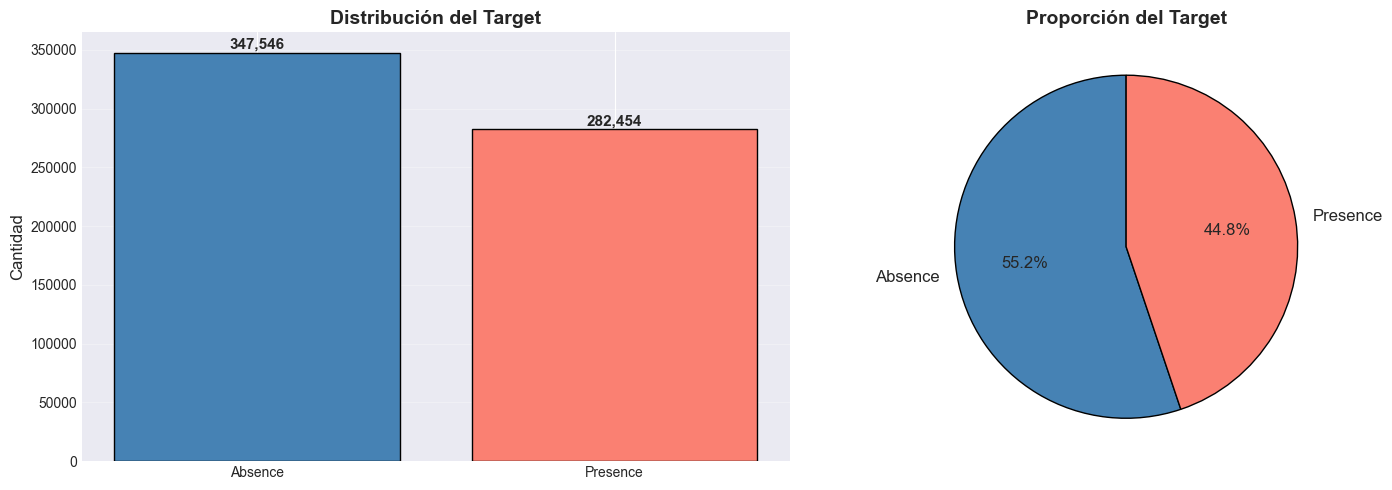

✓ Distribución del target visualizada


In [6]:
# Distribución del target
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
colors = ["steelblue", "salmon"]
counts = df["Heart Disease"].value_counts()
axes[0].bar(counts.index, counts.values, color=colors, edgecolor="black")
for i, (label, val) in enumerate(counts.items()):
    axes[0].text(i, val + len(df)*0.005, f"{val:,}", ha="center", fontsize=11, fontweight="bold")
axes[0].set_ylabel("Cantidad", fontsize=12)
axes[0].set_title("Distribución del Target", fontsize=14, fontweight="bold")
axes[0].grid(True, alpha=0.3, axis="y")

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=colors, startangle=90, textprops={"fontsize": 12},
            wedgeprops={"edgecolor": "black", "linewidth": 1})
axes[1].set_title("Proporción del Target", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

print("✓ Distribución del target visualizada")

In [7]:
# Estadísticas descriptivas generales
df[continuous_features].describe()

,Age,BP,Cholesterol,Max HR,ST depression
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,54.136706,130.497433,245.011814,152.816763,0.716028
std,8.256301,14.975802,33.681581,19.112927,0.948472
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,223.000000,142.000000,0.000000
50%,54.000000,130.000000,243.000000,157.000000,0.100000
75%,60.000000,140.000000,269.000000,166.000000,1.400000
max,77.000000,200.000000,564.000000,202.000000,6.200000


## 4. Análisis de Variables Continuas vs Target

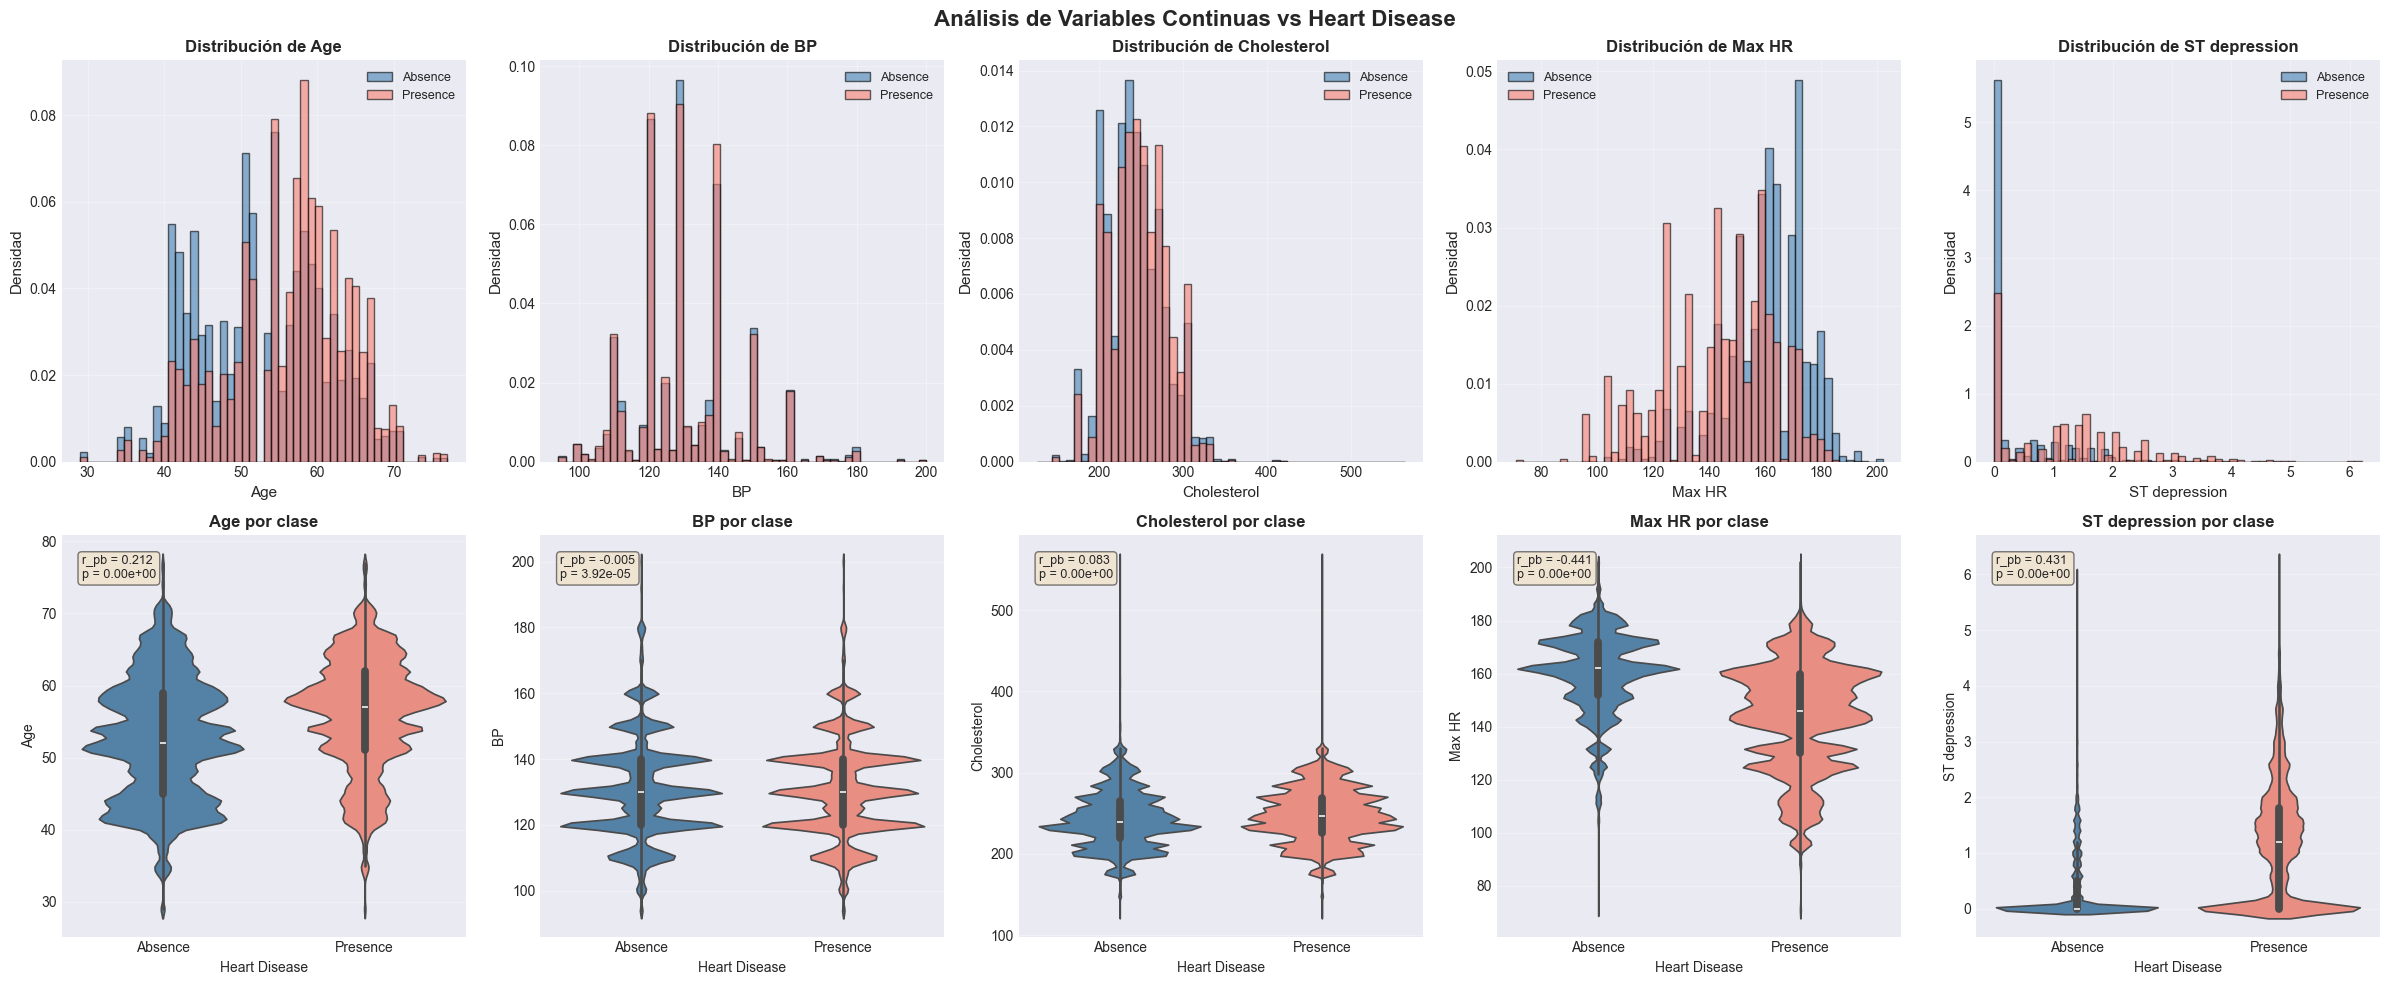

✓ Análisis de variables continuas completado


In [8]:
# Distribuciones por clase + violin plots
fig, axes = plt.subplots(2, 5, figsize=(24, 10))
fig.suptitle("Análisis de Variables Continuas vs Heart Disease", fontsize=16, fontweight="bold")

for idx, var in enumerate(continuous_features):
    # Fila 1: Histogramas superpuestos por clase
    ax1 = axes[0, idx]
    for label, color in zip(["Absence", "Presence"], ["steelblue", "salmon"]):
        subset = df[df["Heart Disease"] == label][var]
        ax1.hist(subset, bins=50, alpha=0.6, color=color, edgecolor="black",
                 label=label, density=True)
    ax1.set_xlabel(var, fontsize=11)
    ax1.set_ylabel("Densidad", fontsize=11)
    ax1.set_title(f"Distribución de {var}", fontweight="bold")
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # Fila 2: Violin plots
    ax2 = axes[1, idx]
    sns.violinplot(data=df, x="Heart Disease", y=var, ax=ax2,
                   palette={"Absence": "steelblue", "Presence": "salmon"},
                   inner="box", order=["Absence", "Presence"])
    ax2.set_title(f"{var} por clase", fontweight="bold")

    # Point-biserial correlation
    corr, pval = stats.pointbiserialr(df["target"], df[var])
    ax2.text(0.05, 0.95, f"r_pb = {corr:.3f}\np = {pval:.2e}",
             transform=ax2.transAxes, fontsize=9, verticalalignment="top",
             bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))
    ax2.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("✓ Análisis de variables continuas completado")

In [9]:
# Correlaciones punto-biserial con el target
print("\n" + "="*80)
print("CORRELACIONES PUNTO-BISERIAL CON HEART DISEASE (Variables Continuas)")
print("="*80)

pb_results = {}
for var in continuous_features:
    corr, pval = stats.pointbiserialr(df["target"], df[var])
    pb_results[var] = {"corr": corr, "pval": pval}

pb_sorted = sorted(pb_results.items(), key=lambda x: abs(x[1]["corr"]), reverse=True)
for var, res in pb_sorted:
    bar = '█' * int(abs(res['corr']) * 50)
    sign = "+" if res['corr'] > 0 else "-"
    print(f"{var:20s}: r_pb = {res['corr']:+7.4f}  (p = {res['pval']:.2e})  {bar}")
print("="*80)


CORRELACIONES PUNTO-BISERIAL CON HEART DISEASE (Variables Continuas)
Max HR              : r_pb = -0.4410  (p = 0.00e+00)  ██████████████████████
ST depression       : r_pb = +0.4306  (p = 0.00e+00)  █████████████████████
Age                 : r_pb = +0.2121  (p = 0.00e+00)  ██████████
Cholesterol         : r_pb = +0.0828  (p = 0.00e+00)  ████
BP                  : r_pb = -0.0052  (p = 3.92e-05)  


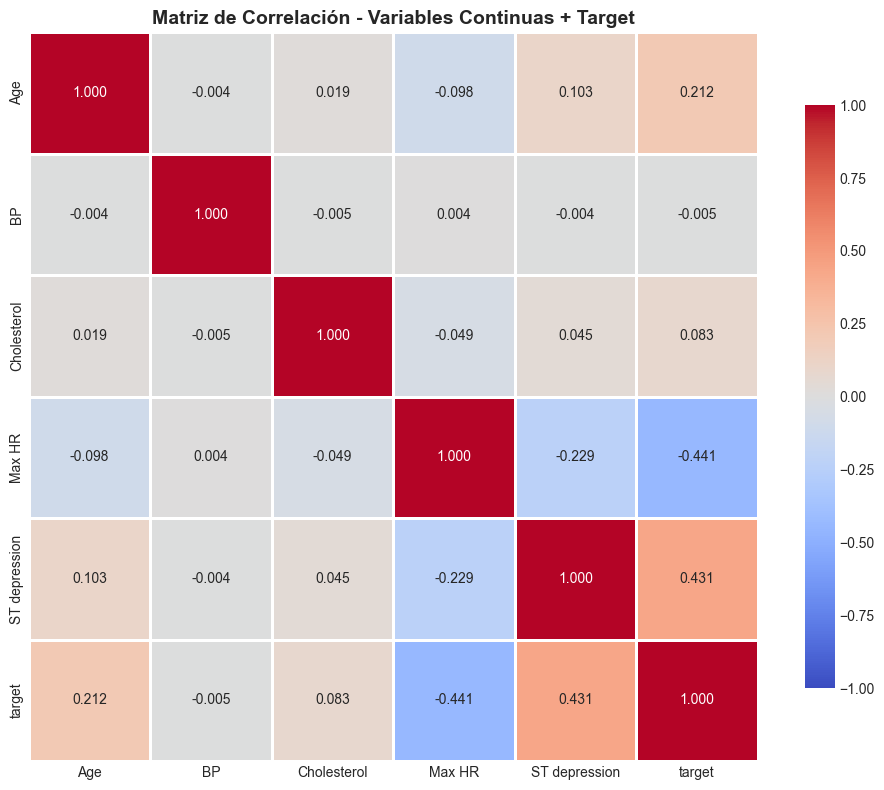

✓ Matriz de correlación generada


In [10]:
# Matriz de correlación
corr_data = df[continuous_features + ["target"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_data, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1)
plt.title("Matriz de Correlación - Variables Continuas + Target", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("✓ Matriz de correlación generada")

## 5. Análisis de Variables Categóricas vs Target

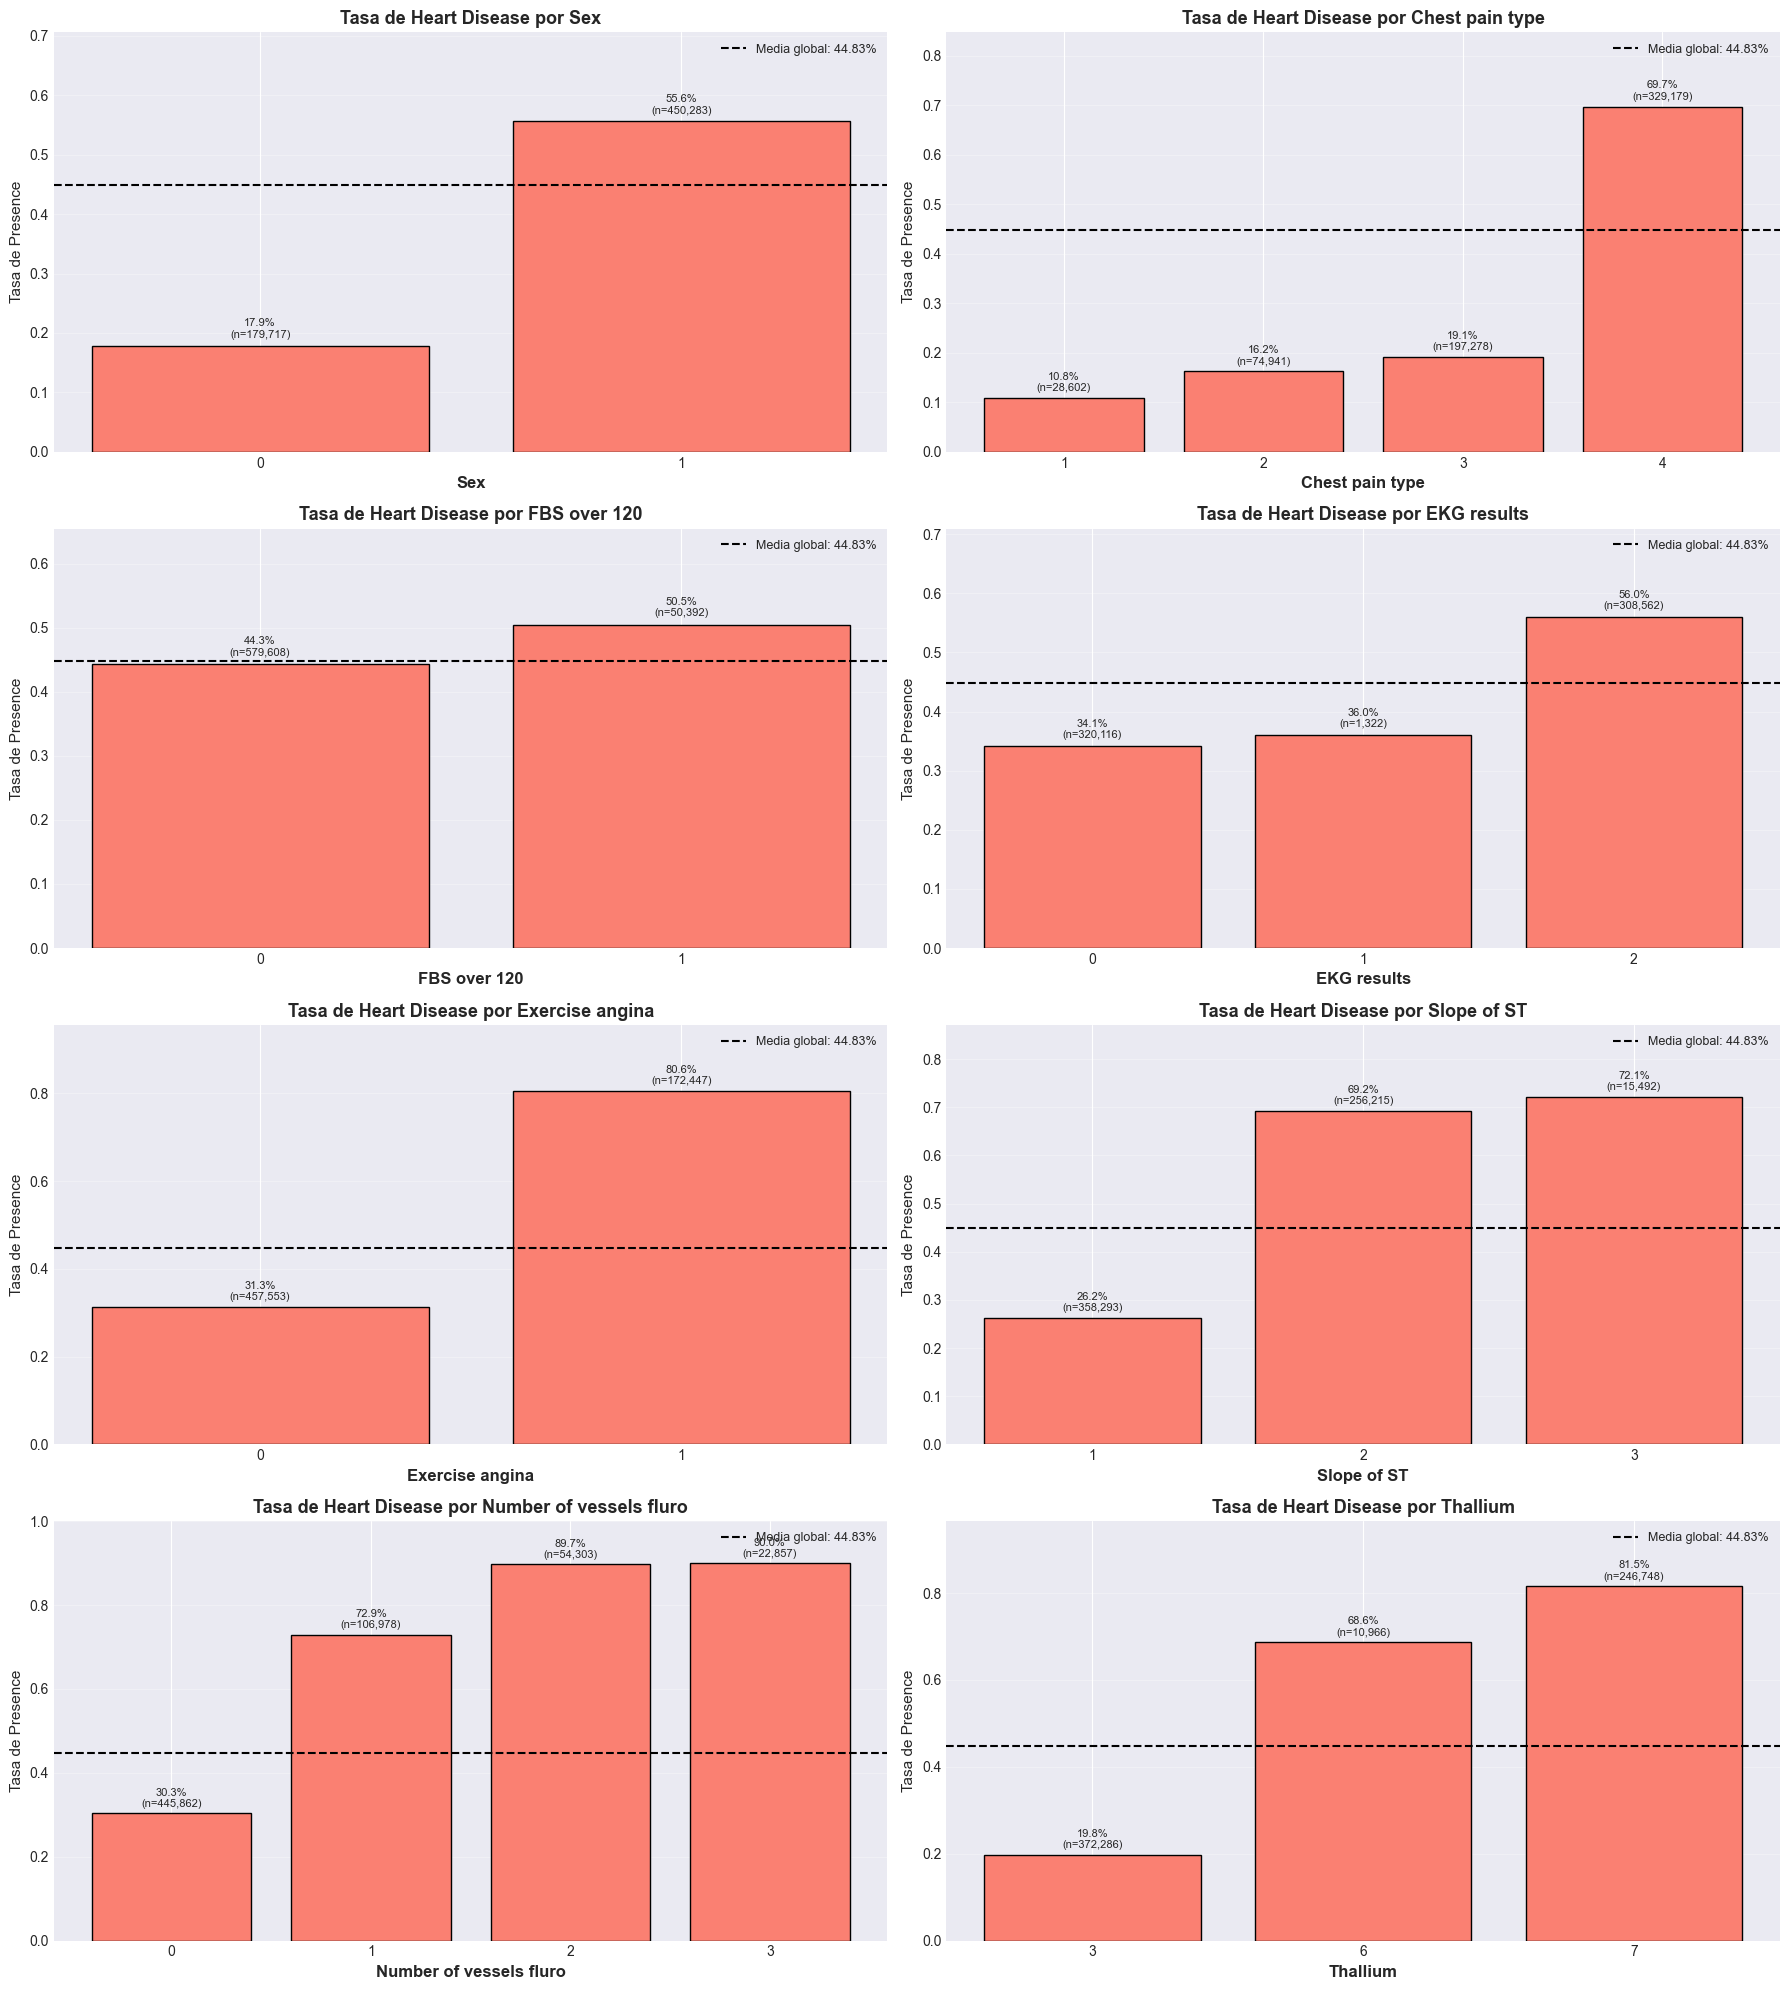

✓ Análisis de variables categóricas completado


In [11]:
# Tasa de enfermedad por categoría + distribución de cada variable
fig, axes = plt.subplots(4, 2, figsize=(18, 20))
axes = axes.flatten()

for idx, var in enumerate(categorical_features):
    ax = axes[idx]

    # Tasa de Presence por categoría
    rate = df.groupby(var)["target"].mean().sort_index()
    counts_cat = df[var].value_counts().sort_index()

    bars = ax.bar(rate.index.astype(str), rate.values, color="salmon", edgecolor="black")
    ax.axhline(df["target"].mean(), color="black", linestyle="--", linewidth=1.5,
               label=f"Media global: {df['target'].mean():.2%}")

    # Anotar cada barra con tasa y count
    for bar, cat in zip(bars, rate.index):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f"{height:.1%}\n(n={counts_cat[cat]:,})",
                ha="center", va="bottom", fontsize=8)

    ax.set_xlabel(var, fontsize=12, fontweight="bold")
    ax.set_ylabel("Tasa de Presence", fontsize=11)
    ax.set_title(f"Tasa de Heart Disease por {var}", fontsize=13, fontweight="bold")
    ax.set_ylim(0, min(rate.max() + 0.15, 1.0))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("✓ Análisis de variables categóricas completado")

In [12]:
# Test Chi-cuadrado para cada variable categórica
print("\n" + "="*80)
print("ANÁLISIS ESTADÍSTICO POR VARIABLE CATEGÓRICA (Chi-cuadrado)")
print("="*80)

chi2_results = {}

for var in categorical_features:
    print(f"\n{var.upper()}:")
    print("-" * 70)

    # Tabla cruzada
    ct = pd.crosstab(df[var], df["Heart Disease"])

    # Tasa por categoría
    rate = df.groupby(var)["target"].agg(["count", "mean", "sum"]).sort_values("mean", ascending=False)
    rate.columns = ["n", "tasa_presence", "n_presence"]
    rate["n_absence"] = rate["n"] - rate["n_presence"]
    print(rate.to_string())

    # Chi-cuadrado
    chi2, pval, dof, expected = stats.chi2_contingency(ct)
    # Cramér's V
    n = ct.sum().sum()
    min_dim = min(ct.shape[0], ct.shape[1]) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

    chi2_results[var] = {"chi2": chi2, "pval": pval, "cramers_v": cramers_v}

    print(f"\nChi² = {chi2:.2f}, p-value = {pval:.2e}, Cramér's V = {cramers_v:.4f}")

    if pval < 0.001:
        print("✓✓✓ Variable MUY significativa (p < 0.001)")
    elif pval < 0.05:
        print("✓✓ Variable significativa (p < 0.05)")
    elif pval < 0.1:
        print("✓ Variable marginalmente significativa (p < 0.1)")
    else:
        print("✗ Variable NO significativa (p >= 0.1)")

print("\n" + "="*80)


ANÁLISIS ESTADÍSTICO POR VARIABLE CATEGÓRICA (Chi-cuadrado)

SEX:
----------------------------------------------------------------------
          n  tasa_presence  n_presence  n_absence
Sex                                              
1    450283       0.555933      250327     199956
0    179717       0.178764       32127     147590

Chi² = 73878.22, p-value = 0.00e+00, Cramér's V = 0.3424
✓✓✓ Variable MUY significativa (p < 0.001)

CHEST PAIN TYPE:
----------------------------------------------------------------------
                      n  tasa_presence  n_presence  n_absence
Chest pain type                                              
4                329179       0.697478      229595      99584
3                197278       0.190665       37614     159664
2                 74941       0.162181       12154      62787
1                 28602       0.108069        3091      25511

Chi² = 173770.66, p-value = 0.00e+00, Cramér's V = 0.5252
✓✓✓ Variable MUY significativa (p < 0.001

## 6. Ranking de Variables - Importancia Combinada

In [13]:
# Ranking combinado
# Para continuas: |correlación punto-biserial|
# Para categóricas: Cramér's V
# Ambos están en escala 0-1, así que se pueden comparar directamente

importance = {}
for var in continuous_features:
    importance[var] = abs(pb_results[var]["corr"])
for var in categorical_features:
    importance[var] = chi2_results[var]["cramers_v"]

importance_series = pd.Series(importance).sort_values(ascending=False)

# Normalizar a 0-100
importance_norm = (importance_series / importance_series.max()) * 100

print("\n" + "="*80)
print("RANKING FINAL DE VARIABLES (Importancia Normalizada 0-100)")
print("="*80)
for i, (var, score) in enumerate(importance_norm.items(), 1):
    var_type = "CON" if var in continuous_features else "CAT"
    bar = '█' * int(score / 5)
    print(f"{i:2d}. {var:25s} [{var_type}]: {score:6.2f}  {bar}")
print("="*80)


RANKING FINAL DE VARIABLES (Importancia Normalizada 0-100)
 1. Thallium                  [CAT]: 100.00  ████████████████████
 2. Chest pain type           [CAT]:  86.69  █████████████████
 3. Number of vessels fluro   [CAT]:  76.47  ███████████████
 4. Exercise angina           [CAT]:  72.94  ██████████████
 5. Max HR                    [CON]:  72.79  ██████████████
 6. ST depression             [CON]:  71.08  ██████████████
 7. Slope of ST               [CAT]:  70.94  ██████████████
 8. Sex                       [CAT]:  56.53  ███████████
 9. EKG results               [CAT]:  36.17  ███████
10. Age                       [CON]:  35.01  ███████
11. Cholesterol               [CON]:  13.66  ██
12. FBS over 120              [CAT]:   5.54  █
13. BP                        [CON]:   0.86  


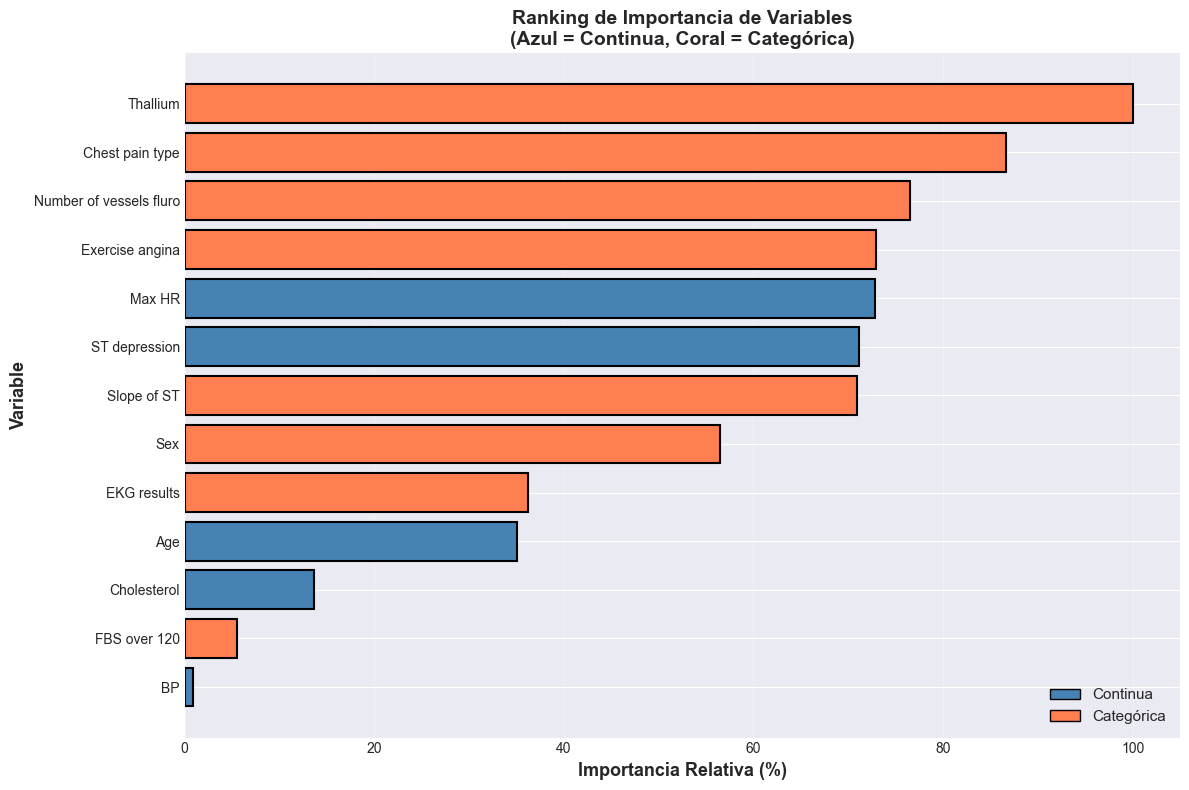

✓ Ranking de importancia visualizado


In [14]:
# Visualizar ranking
plt.figure(figsize=(12, 8))
colors = ["steelblue" if var in continuous_features else "coral" for var in importance_norm.index]
plt.barh(importance_norm.index, importance_norm.values, color=colors, edgecolor="black", linewidth=1.5)
plt.xlabel("Importancia Relativa (%)", fontsize=13, fontweight="bold")
plt.ylabel("Variable", fontsize=13, fontweight="bold")
plt.title("Ranking de Importancia de Variables\n(Azul = Continua, Coral = Categórica)",
          fontsize=14, fontweight="bold")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis="x")

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="steelblue", edgecolor="black", label="Continua"),
    Patch(facecolor="coral", edgecolor="black", label="Categórica")
]
plt.legend(handles=legend_elements, loc="lower right", fontsize=11)

plt.tight_layout()
plt.show()

print("✓ Ranking de importancia visualizado")

## 7. Pairplot de Top Variables

Top 5 variables para pairplot:
  1. Thallium
  2. Chest pain type
  3. Number of vessels fluro
  4. Exercise angina
  5. Max HR

Generando pairplot con muestra de 5,000 registros...


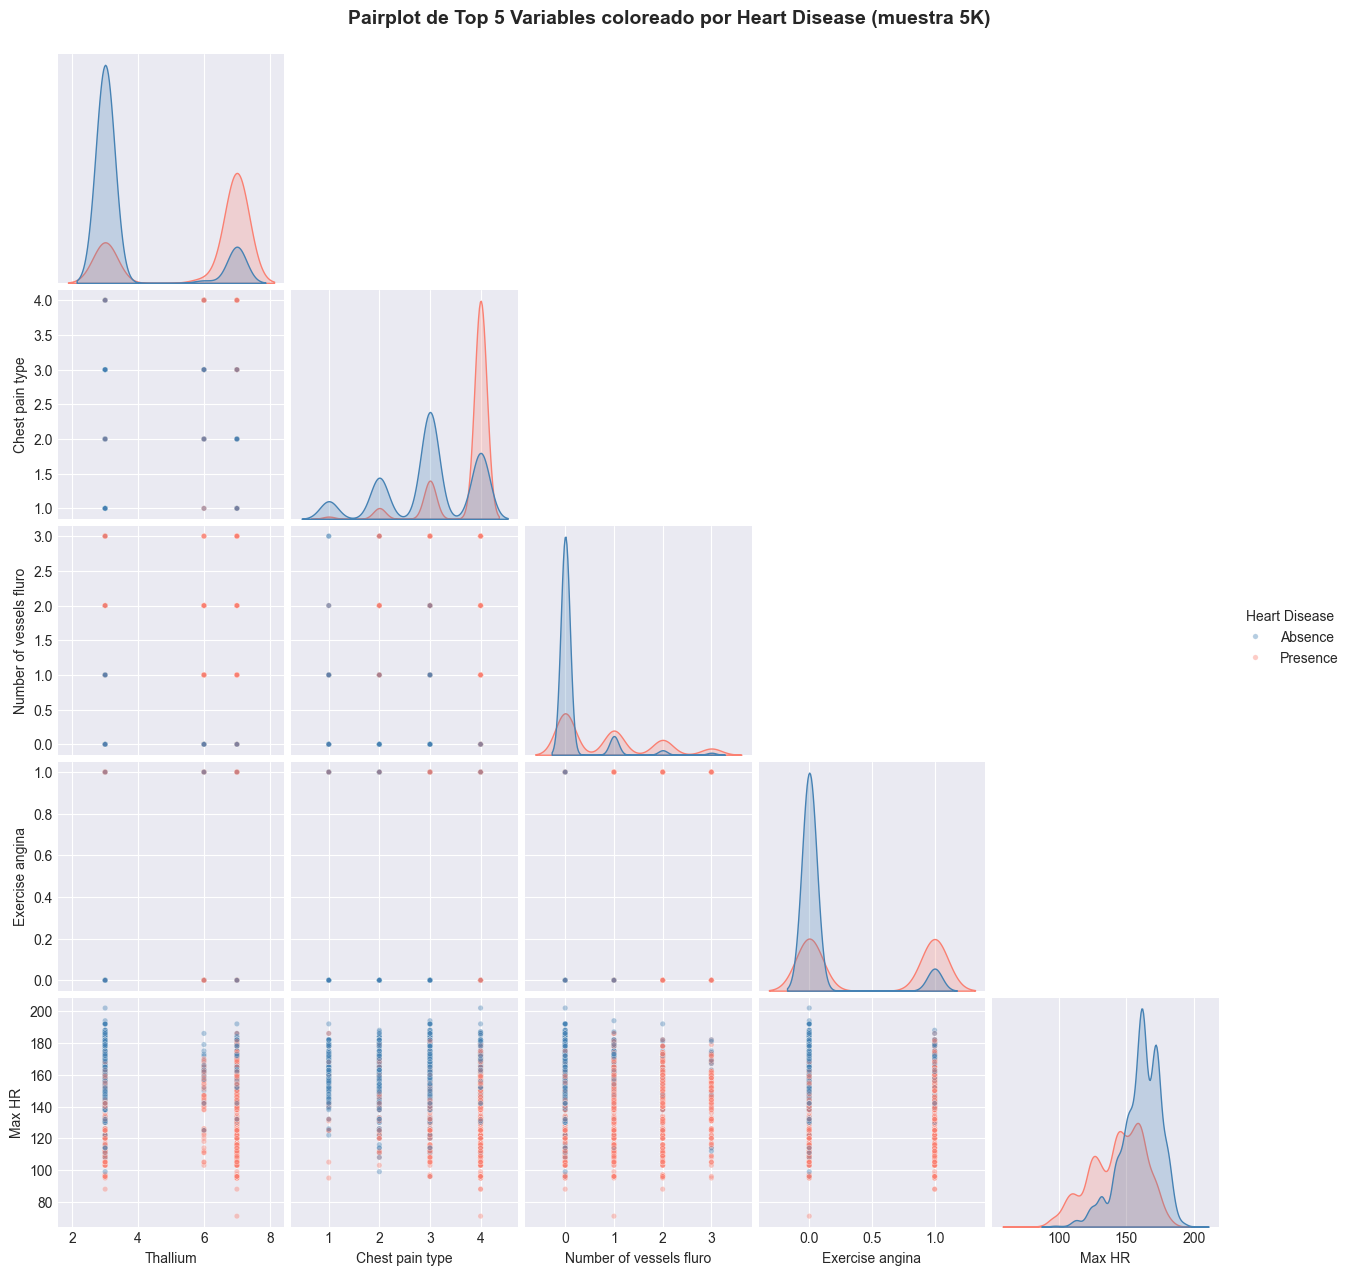

✓ Pairplot generado


In [15]:
# Pairplot con las top 5 variables + target (muestra de 5K para velocidad)
top_5_vars = importance_norm.head(5).index.tolist()

print(f"Top 5 variables para pairplot:")
for i, var in enumerate(top_5_vars, 1):
    print(f"  {i}. {var}")

plot_data = df[top_5_vars + ["Heart Disease"]].sample(5000, random_state=42)

print(f"\nGenerando pairplot con muestra de {len(plot_data):,} registros...")
sns.pairplot(plot_data, hue="Heart Disease", diag_kind="kde",
             palette={"Absence": "steelblue", "Presence": "salmon"},
             plot_kws={"alpha": 0.4, "s": 15}, corner=True)
plt.suptitle("Pairplot de Top 5 Variables coloreado por Heart Disease (muestra 5K)",
             y=1.02, fontsize=14, fontweight="bold")
plt.show()

print("✓ Pairplot generado")

## 8. Conclusiones y Recomendaciones

In [16]:
# Resumen de hallazgos
print("\n" + "="*80)
print("RESUMEN DE ANÁLISIS EXPLORATORIO")
print("="*80)

# Top 3
top_3 = importance_norm.head(3)
print(f"\nTOP 3 VARIABLES MÁS IMPORTANTES:")
for i, (var, imp) in enumerate(top_3.items(), 1):
    var_type = "Continua" if var in continuous_features else "Categórica"
    print(f"  {i}. {var} ({var_type}): {imp:.2f}%")

# Continuas
print(f"\nMEJORES CORRELACIONES PUNTO-BISERIAL (Variables Continuas):")
for var, res in sorted(pb_results.items(), key=lambda x: abs(x[1]['corr']), reverse=True)[:3]:
    print(f"  - {var}: r_pb = {res['corr']:+.4f}")

# Categóricas
print(f"\nVARIABLES CATEGÓRICAS MÁS SIGNIFICATIVAS (Chi²):")
for var in sorted(chi2_results, key=lambda x: chi2_results[x]['cramers_v'], reverse=True)[:3]:
    v = chi2_results[var]['cramers_v']
    p = chi2_results[var]['pval']
    print(f"  - {var}: Cramér's V = {v:.4f}, p = {p:.2e}")

# Recomendaciones
print(f"\nRECOMENDACIONES PARA MODELADO:")
print("-" * 80)
print("1. Variables obligatorias (alta importancia):")
for var in importance_norm.head(5).index:
    print(f"   • {var}")

print(f"\n2. Variables opcionales (importancia media):")
for var in importance_norm.iloc[5:9].index:
    print(f"   • {var}")

print(f"\n3. Variables de baja prioridad:")
for var in importance_norm.tail(4).index:
    print(f"   • {var}")

print("\n" + "="*80)
print("PRÓXIMOS PASOS SUGERIDOS")
print("="*80)
print("1. Entrenar modelo baseline con todas las variables")
print("2. Entrenar modelo con Top 5 variables")
print("3. Probar feature engineering (interacciones entre top variables)")
print("4. Comparar métricas (AUC, F1) y seleccionar el mejor")
print("5. Optimizar hiperparámetros del modelo seleccionado")
print("="*80)


RESUMEN DE ANÁLISIS EXPLORATORIO

TOP 3 VARIABLES MÁS IMPORTANTES:
  1. Thallium (Categórica): 100.00%
  2. Chest pain type (Categórica): 86.69%
  3. Number of vessels fluro (Categórica): 76.47%

MEJORES CORRELACIONES PUNTO-BISERIAL (Variables Continuas):
  - Max HR: r_pb = -0.4410
  - ST depression: r_pb = +0.4306
  - Age: r_pb = +0.2121

VARIABLES CATEGÓRICAS MÁS SIGNIFICATIVAS (Chi²):
  - Thallium: Cramér's V = 0.6058, p = 0.00e+00
  - Chest pain type: Cramér's V = 0.5252, p = 0.00e+00
  - Number of vessels fluro: Cramér's V = 0.4632, p = 0.00e+00

RECOMENDACIONES PARA MODELADO:
--------------------------------------------------------------------------------
1. Variables obligatorias (alta importancia):
   • Thallium
   • Chest pain type
   • Number of vessels fluro
   • Exercise angina
   • Max HR

2. Variables opcionales (importancia media):
   • ST depression
   • Slope of ST
   • Sex
   • EKG results

3. Variables de baja prioridad:
   • Age
   • Cholesterol
   • FBS over 120
 

## 9. Resumen Final

In [17]:
print("\n" + "="*100)
print("RESUMEN FINAL - ANÁLISIS EXPLORATORIO VISUAL")
print("="*100)

print(f"\nDATASET:")
print(f"  - Registros analizados: {len(df):,}")
print(f"  - Variables totales: {len(all_features)}")
print(f"  - Continuas: {len(continuous_features)}")
print(f"  - Categóricas: {len(categorical_features)}")
print(f"  - Balance del target: Absence {(1 - df['target'].mean()):.1%} / Presence {df['target'].mean():.1%}")

print(f"\nANÁLISIS REALIZADO:")
print("  ✓ Histogramas superpuestos por clase (continuas)")
print("  ✓ Violin plots por clase (continuas)")
print("  ✓ Correlaciones punto-biserial (continuas vs target)")
print("  ✓ Tasas de presencia por categoría (categóricas)")
print("  ✓ Tests Chi-cuadrado y Cramér's V (categóricas vs target)")
print("  ✓ Ranking combinado de importancia")
print("  ✓ Pairplot de top 5 variables")

print(f"\nTOP 5 VARIABLES SELECCIONADAS:")
for i, var in enumerate(importance_norm.head(5).index, 1):
    var_type = "CON" if var in continuous_features else "CAT"
    print(f"  {i}. {var} [{var_type}] - Score: {importance_norm[var]:.2f}")

print("\n" + "="*100)
print("✅ ANÁLISIS EXPLORATORIO COMPLETADO EXITOSAMENTE")
print("="*100)


RESUMEN FINAL - ANÁLISIS EXPLORATORIO VISUAL

DATASET:
  - Registros analizados: 630,000
  - Variables totales: 13
  - Continuas: 5
  - Categóricas: 8
  - Balance del target: Absence 55.2% / Presence 44.8%

ANÁLISIS REALIZADO:
  ✓ Histogramas superpuestos por clase (continuas)
  ✓ Violin plots por clase (continuas)
  ✓ Correlaciones punto-biserial (continuas vs target)
  ✓ Tasas de presencia por categoría (categóricas)
  ✓ Tests Chi-cuadrado y Cramér's V (categóricas vs target)
  ✓ Ranking combinado de importancia
  ✓ Pairplot de top 5 variables

TOP 5 VARIABLES SELECCIONADAS:
  1. Thallium [CAT] - Score: 100.00
  2. Chest pain type [CAT] - Score: 86.69
  3. Number of vessels fluro [CAT] - Score: 76.47
  4. Exercise angina [CAT] - Score: 72.94
  5. Max HR [CON] - Score: 72.79

✅ ANÁLISIS EXPLORATORIO COMPLETADO EXITOSAMENTE
